# XBeach Timeseries Forcing Tutorial

This tutorial demonstrates how to generate XBeach forcing from **single-location
timeseries data** such as CSV files or pandas DataFrames.

## When to Use This Approach

Use timeseries forcing when your input data:
- Comes from a **single location** (e.g., buoy, tide gauge, weather station)
- Is stored in **tabular format** (CSV, DataFrame) without spatial coordinates
- Represents conditions that are **uniform across your model domain**
- Does not require spatial selection or interpolation

This is common for nearshore XBeach applications where the domain is small enough
that forcing can be assumed spatially uniform.

For **geolocated data** (gridded reanalysis, station networks with coordinates),
see the **Forcing Tutorial** which covers spatial selection and interpolation.

## What You'll Learn

- Generate wind forcing from CSV timeseries
- Generate tide/water level forcing from CSV or tidal constituents
- Generate wave boundaries from CSV wave parameters
- Combine all forcing types in a complete model configuration

In [1]:
from pathlib import Path
from datetime import timedelta
import shutil
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Setup

In [2]:
# Data and output directories
DATA_DIR = Path("../../../../rompy-xbeach/tests/data")
OUT_DIR = Path("timeseries-forcing-tutorial-output")

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir()

In [3]:
from rompy.core.time import TimeRange
from rompy_xbeach.grid import RegularGrid

# Model times
times = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")

# Model grid
grid = RegularGrid(
    ori=dict(x=115.594239, y=-32.641104, crs="epsg:4326"),
    alfa=347.0,
    dx=10,
    dy=15,
    nx=230,
    ny=220,
    crs="28350",
)

In [4]:
def print_params(params: dict, filename: str = "params.txt"):
    """Display parameters in a text-editor style format."""
    border = "─" * 60
    print(f"┌{border}┐")
    print(f"│ {filename:<58} │")
    print(f"├{border}┤")
    for k, v in params.items():
        line = f"{k} = {v}"
        print(f"│ {line:<58} │")
    print(f"└{border}┘")


def print_file(filepath, title=None, cols=60):
    """Display file contents in a text-editor style format."""
    inner_width = cols - 2  # Account for "│ " and " │" borders
    border = "─" * cols
    title = title or filepath.name
    
    # Truncate title if needed
    if len(title) > inner_width:
        title = title[:inner_width-3] + "..."
    
    print(f"┌{border}┐")
    print(f"│ {title:<{inner_width}} │")  # Use nested braces for variable width
    print(f"├{border}┤")
    for line in filepath.read_text().strip().split("\n"):
        # Truncate long lines
        if len(line) > inner_width:
            line = line[:inner_width-3] + "..."
        print(f"│ {line:<{inner_width}} │")
    print(f"└{border}┘")


---
# Part 1: Wind Forcing from Timeseries

The `WindPoint` class generates wind forcing from single-location timeseries data.
The data is used directly without spatial selection - it is assumed to represent
conditions applicable to your model domain.

## Input Data Format

Your CSV file should have:
- A **time column** with datetime values
- Either **speed and direction** columns, or **u and v** component columns

In [5]:
# Let's look at the example wind CSV file
wind_csv = DATA_DIR / "wind.csv"
df_wind_source = pd.read_csv(wind_csv, parse_dates=["time"])
df_wind_source

,time,u10,v10,wspd,wdir
0,2023-01-01 00:00:00,-3.633700,6.260819,7.238897,149.86966
1,2023-01-01 01:00:00,-3.476098,6.245619,7.147798,150.90118
2,2023-01-01 02:00:00,-3.082727,6.410751,7.113433,154.31857
3,2023-01-01 03:00:00,-2.603631,6.792392,7.274303,159.02739
4,2023-01-01 04:00:00,-2.139115,7.232939,7.542627,163.52463
5,2023-01-01 05:00:00,-1.715853,7.784421,7.971284,167.56956
6,2023-01-01 06:00:00,-1.418075,8.242932,8.364022,170.23866
7,2023-01-01 07:00:00,-1.097202,8.703077,8.771967,172.81460
8,2023-01-01 08:00:00,-0.881369,9.128032,9.170484,174.48483
9,2023-01-01 09:00:00,-0.844598,9.506232,9.543678,174.92279


## 1.1 Wind from Speed and Direction

In [6]:
from rompy.core.source import SourceTimeseriesCSV
from rompy_xbeach.data.wind import WindPoint, WindScalar, WindVector

In [7]:
destdir = OUT_DIR / "wind_scalar"
destdir.mkdir(exist_ok=True)

# Define the CSV source
source = SourceTimeseriesCSV(
    filename=DATA_DIR / "wind.csv",
    tcol="time",  # Name of the time column
)

# Create wind forcing with scalar variables (speed and direction)
wind = WindPoint(
    source=source,
    wind_vars=WindScalar(spd="wspd", dir="wdir"),
)

# Generate the forcing file
params = wind.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ windfile = wind-20230101T000000-20230101T120000.txt        │
└────────────────────────────────────────────────────────────┘


In [8]:
# Inspect the generated wind file
windfile = destdir / params["windfile"]
print_file(windfile)

┌────────────────────────────────────────────────────────────┐
│ wind-20230101T000000-20230101T120000.txt                   │
├────────────────────────────────────────────────────────────┤
│ 0.00       7.24     149.87                                 │
│    3600.00       7.15     150.90                           │
│    7200.00       7.11     154.32                           │
│   10800.00       7.27     159.03                           │
│   14400.00       7.54     163.52                           │
│   18000.00       7.97     167.57                           │
│   21600.00       8.36     170.24                           │
│   25200.00       8.77     172.81                           │
│   28800.00       9.17     174.48                           │
│   32400.00       9.54     174.92                           │
│   36000.00       9.78     177.59                           │
│   39600.00      10.09     175.46                           │
│   43200.00      10.19     172.35                     

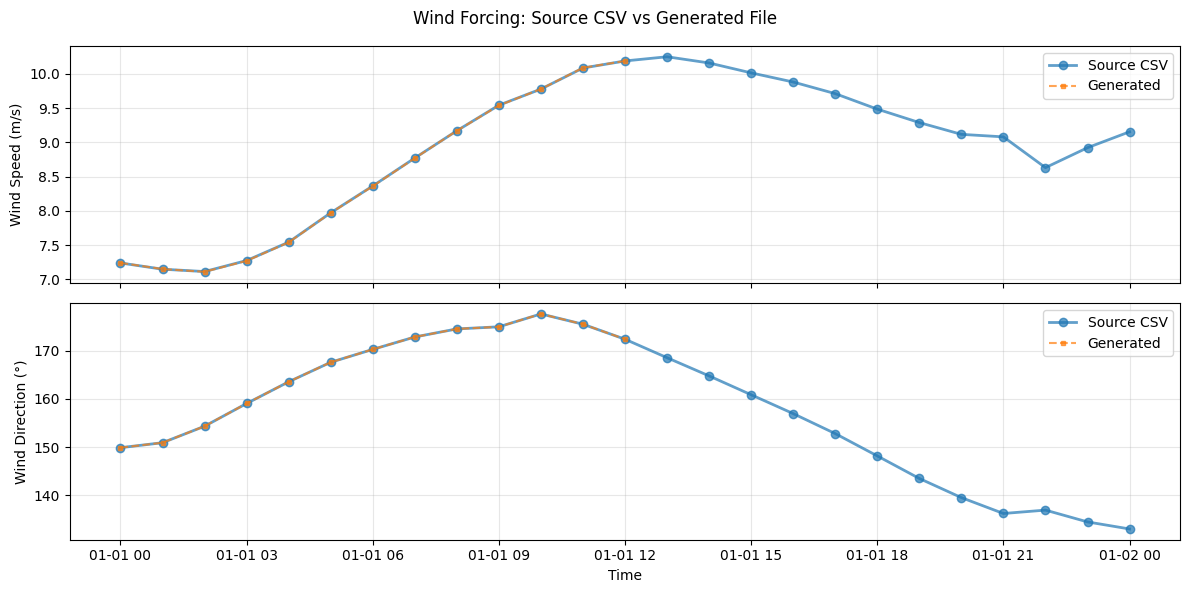

In [9]:
# Load and compare source vs generated data
df_generated = pd.read_csv(windfile, header=None, sep=r"\s+", names=["tsec", "wspd", "wdir"])
df_generated["time"] = [times.start + timedelta(seconds=s) for s in df_generated.tsec]
df_generated.set_index("time", inplace=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Wind speed
ax1.plot(df_wind_source.time, df_wind_source.wspd, "o-", linewidth=2, label="Source CSV", alpha=0.7)
ax1.plot(df_generated.index, df_generated.wspd, "s--", markersize=3, label="Generated", alpha=0.7)
ax1.set_ylabel("Wind Speed (m/s)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wind direction
ax2.plot(df_wind_source.time, df_wind_source.wdir, "o-", linewidth=2, label="Source CSV", alpha=0.7)
ax2.plot(df_generated.index, df_generated.wdir, "s--", markersize=3, label="Generated", alpha=0.7)
ax2.set_ylabel("Wind Direction (°)")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Wind Forcing: Source CSV vs Generated File")
plt.tight_layout()

## 1.2 Wind from U and V Components

If your data has u and v wind components instead of speed and direction:

In [10]:
# WindVector is used for u/v component data
# wind = WindPoint(
#     source=source,
#     wind_vars=WindVector(u="u10", v="v10"),
# )

print("Use WindVector(u='u_col', v='v_col') for u/v component data")
print("Use WindScalar(spd='speed_col', dir='dir_col') for speed/direction data")

Use WindVector(u='u_col', v='v_col') for u/v component data
Use WindScalar(spd='speed_col', dir='dir_col') for speed/direction data


---
# Part 2: Tide/Water Level Forcing from CSV

Two approaches for tide forcing from timeseries:

1. **TideConsPoint**: Generate tide from harmonic constituents (amplitude, phase)
2. **WaterLevelPoint**: Use water level timeseries directly

## 2.1 Tide from Constituents (`TideConsPoint`)

If you have tidal harmonic constituents for your site (e.g., from harmonic analysis
of tide gauge data), you can generate tide timeseries.

In [11]:
# Let's look at the example constituents CSV
cons_csv = DATA_DIR / "tide_cons_station.csv"
df_cons = pd.read_csv(cons_csv)
df_cons

,constituent,amplitude,phase
0,M2,0.042485,63.434948
1,S2,0.046141,60.101093
2,N2,0.016553,115.016884
3,K2,0.015000,53.130100
4,K1,0.182538,184.398710
5,O1,0.129139,177.336990
6,P1,0.057009,178.994900
7,Q1,0.028443,169.875320
8,MM,0.002000,90.000000
9,MF,0.002000,90.000000


In [12]:
from rompy_xbeach.source import SourceTideConsPointCSV
from rompy_xbeach.data.waterlevel import TideConsPoint

In [13]:
destdir = OUT_DIR / "tide_cons"
destdir.mkdir(exist_ok=True)

# Define the constituents source
source = SourceTideConsPointCSV(
    filename=DATA_DIR / "tide_cons_station.csv",
    acol="amplitude",   # Amplitude column
    pcol="phase",       # Phase column
    ccol="constituent", # Constituent name column
)

# Create tide forcing
tide = TideConsPoint(source=source)

# Generate the forcing file
params = tide.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ zs0file = tide-20230101T000000-20230101T120000.txt         │
│ tideloc = 1                                                │
│ tidelen = 13                                               │
└────────────────────────────────────────────────────────────┘


In [14]:
# Inspect the generated tide file
tidefile = destdir / params["zs0file"]
print_file(tidefile)

┌────────────────────────────────────────────────────────────┐
│ tide-20230101T000000-20230101T120000.txt                   │
├────────────────────────────────────────────────────────────┤
│ 0.00      -0.20                                            │
│    3600.00      -0.15                                      │
│    7200.00      -0.09                                      │
│   10800.00      -0.02                                      │
│   14400.00       0.06                                      │
│   18000.00       0.13                                      │
│   21600.00       0.19                                      │
│   25200.00       0.24                                      │
│   28800.00       0.26                                      │
│   32400.00       0.26                                      │
│   36000.00       0.23                                      │
│   39600.00       0.20                                      │
│   43200.00       0.15                                

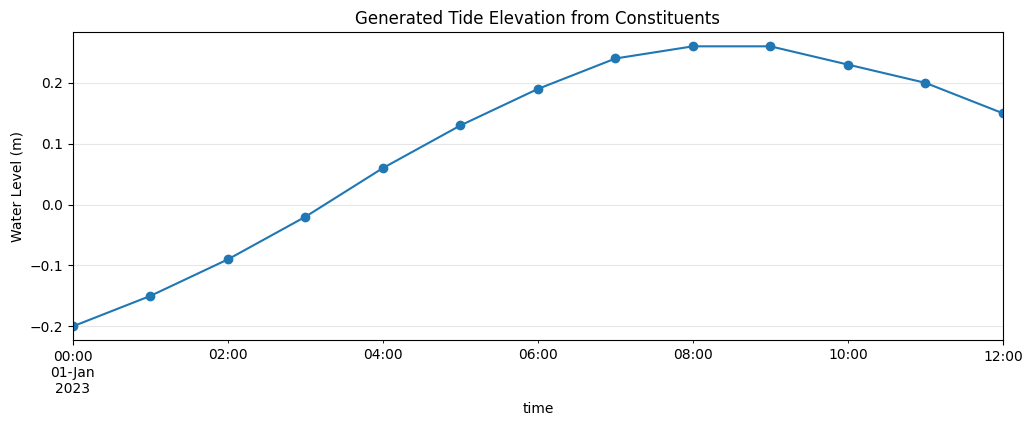

In [15]:
# Plot the generated tide
df_tide = pd.read_csv(tidefile, header=None, sep=r"\s+", names=["tsec", "zs"])
df_tide["time"] = [times.start + timedelta(seconds=s) for s in df_tide.tsec]
df_tide.set_index("time", inplace=True)

fig, ax = plt.subplots(figsize=(12, 4))
df_tide.zs.plot(ax=ax, marker="o")
ax.set_ylabel("Water Level (m)")
ax.set_title("Generated Tide Elevation from Constituents")
ax.grid(True, alpha=0.3)

## 2.2 Water Level from Timeseries (`WaterLevelPoint`)

If you have direct water level measurements (e.g., from a tide gauge or storm surge
model output), use `WaterLevelPoint`.

In [16]:
# Let's look at the example water level CSV
ssh_csv = DATA_DIR / "ssh.csv"
df_ssh_source = pd.read_csv(ssh_csv, parse_dates=["time"])
df_ssh_source

,time,ssh
0,2023-01-01 00:00:00,-0.605216
1,2023-01-01 01:00:00,-0.481833
2,2023-01-01 02:00:00,-0.333268
3,2023-01-01 03:00:00,-0.160836
4,2023-01-01 04:00:00,0.033711
5,2023-01-01 05:00:00,0.245904
6,2023-01-01 06:00:00,0.466581
7,2023-01-01 07:00:00,0.680953
8,2023-01-01 08:00:00,0.869227
9,2023-01-01 09:00:00,1.008872


In [17]:
from rompy_xbeach.data.waterlevel import WaterLevelPoint

In [18]:
destdir = OUT_DIR / "waterlevel"
destdir.mkdir(exist_ok=True)

# Define the timeseries source
source = SourceTimeseriesCSV(
    filename=DATA_DIR / "ssh.csv",
    tcol="time",
)

# Create water level forcing
waterlevel = WaterLevelPoint(
    source=source,
    variables=["ssh"],  # Column name for water level
)

# Generate the forcing file
params = waterlevel.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ zs0file = tide-20230101T000000-20230101T120000.txt         │
│ tideloc = 1                                                │
│ tidelen = 25                                               │
└────────────────────────────────────────────────────────────┘


In [19]:
# Inspect the generated file
zs0file = destdir / params["zs0file"]
print_file(zs0file)

┌────────────────────────────────────────────────────────────┐
│ tide-20230101T000000-20230101T120000.txt                   │
├────────────────────────────────────────────────────────────┤
│ 0.00      -0.61                                            │
│    3600.00      -0.48                                      │
│    7200.00      -0.33                                      │
│   10800.00      -0.16                                      │
│   14400.00       0.03                                      │
│   18000.00       0.25                                      │
│   21600.00       0.47                                      │
│   25200.00       0.68                                      │
│   28800.00       0.87                                      │
│   32400.00       1.01                                      │
│   36000.00       1.08                                      │
│   39600.00       1.06                                      │
│   43200.00       0.95                                

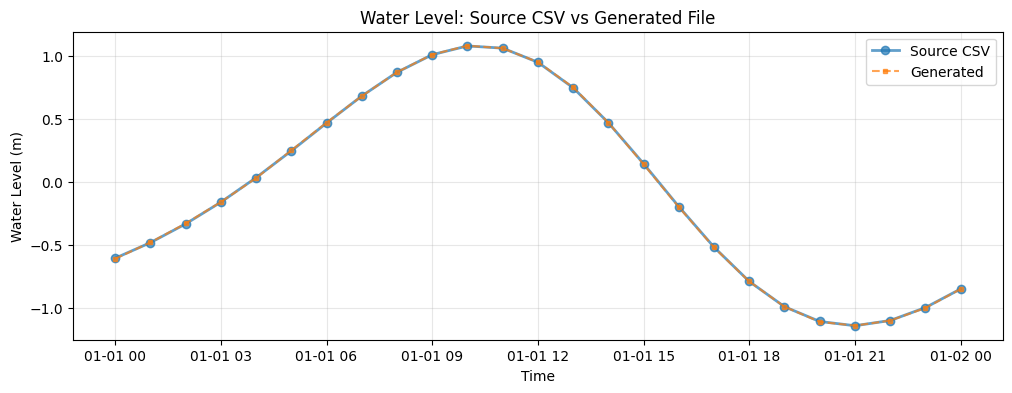

In [20]:
# Compare source vs generated
df_generated = pd.read_csv(zs0file, header=None, sep=r"\s+", names=["tsec", "zs"])
df_generated["time"] = [times.start + timedelta(seconds=s) for s in df_generated.tsec]
df_generated.set_index("time", inplace=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_ssh_source.time, df_ssh_source.ssh, "o-", linewidth=2, label="Source CSV", alpha=0.7)
ax.plot(df_generated.index, df_generated.zs, "s--", markersize=3, label="Generated", alpha=0.7)
ax.set_ylabel("Water Level (m)")
ax.set_xlabel("Time")
ax.set_title("Water Level: Source CSV vs Generated File")
ax.legend()
ax.grid(True, alpha=0.3)

---
# Part 3: Wave Boundary from CSV

Wave boundaries can also be generated from CSV timeseries of wave parameters.
This is useful when you have buoy observations or model output with integrated
wave statistics (Hs, Tp, direction, etc.).

Two boundary types are supported:
- **BoundaryPointParamJons**: JONSWAP spectrum from parameters
- **BoundaryPointParamJonstable**: JONSTABLE (time-varying parameters in single file)

In [21]:
# Let's look at the example wave parameters CSV
wave_csv = DATA_DIR / "wave-params-20230101.csv"
df_wave_source = pd.read_csv(wave_csv, parse_dates=["time"])
df_wave_source.head()

,time,dir,dp,fp,hs,latitude,longitude,pdir0,pdir1,pdp0,...,pqp1,pspr0,pspr1,ptp0,ptp1,spr,t01,t0m1,uwnd,vwnd
0,2023-01-01 00:00:00,232.89560,252.73627,0.060132,1.707824,-32.641106,115.534,219.57253,244.35330,232.98077,...,4.768956,27.379673,13.710990,7.918132,12.299340,25.307690,6.599451,8.965934,0.689011,7.500000
1,2023-01-01 01:00:00,234.19230,252.80220,0.060835,1.751055,-32.641106,115.534,224.07912,247.53131,236.08733,...,5.886374,26.082964,12.470329,8.888790,13.787693,24.765930,6.778571,9.306045,1.476923,7.681319
2,2023-01-01 02:00:00,235.11210,252.84616,0.061209,1.813604,-32.641106,115.534,224.33461,248.84730,236.49344,...,5.977920,25.766481,11.491345,9.040990,14.154168,24.341759,6.894835,9.541429,2.214286,7.880220
3,2023-01-01 03:00:00,235.84065,252.76923,0.062132,1.892176,-32.641106,115.534,223.56044,246.90114,236.56483,...,5.338331,25.754942,11.720650,9.053186,13.510891,23.957144,6.978791,9.691318,3.061539,7.925274
4,2023-01-01 04:00:00,236.24947,251.58241,0.063637,1.984176,-32.641106,115.534,227.62749,250.58173,239.69452,...,5.737210,25.116484,10.828264,10.630878,15.333619,23.699999,6.995605,9.734726,4.023077,8.157144


## 3.1 JONSWAP Boundary (`BoundaryPointParamJons`)

Generate JONSWAP spectrum files from wave parameters.

In [22]:
from rompy_xbeach.data.boundary import BoundaryPointParamJons

In [23]:
destdir = OUT_DIR / "wave_jons"
destdir.mkdir(exist_ok=True)

# Define the wave parameters source
source = SourceTimeseriesCSV(filename=DATA_DIR / "wave-params-20230101.csv")

# Create wave boundary - note the _var suffix for variable name fields
wb = BoundaryPointParamJons(
    source=source,
    hm0_var="phs1",        # Significant wave height column
    tp_var="ptp1",         # Peak period column
    mainang_var="pdp1",    # Mean direction column
    gammajsp_var="ppe1",   # Peak enhancement factor column
    dspr_var="pspr1",      # Directional spreading column
)

# Generate the boundary files
params = wb.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-20230101T000000.txt                          │
└────────────────────────────────────────────────────────────┘


In [24]:
# Inspect the generated bcfile
bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jons-20230101T000000.txt                                   │
├────────────────────────────────────────────────────────────┤
│ gammajsp = 2.52055                                         │
│ Tp = 12.2993                                               │
│ Hm0 = 1.01011                                              │
│ s = 33.9251                                                │
│ mainang = 244.342                                          │
└────────────────────────────────────────────────────────────┘


### Multiple Files (Time-Varying)

Set `filelist=True` to create multiple JONSWAP files, one per timestep:

In [25]:
destdir = OUT_DIR / "wave_jons_multi"
destdir.mkdir(exist_ok=True)

wb = BoundaryPointParamJons(
    source=source,
    filelist=True,  # Create multiple files
    hm0_var="phs1",
    tp_var="ptp1",
    mainang_var="pdp1",
    gammajsp_var="ppe1",
    dspr_var="pspr1",
)

params = wb.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-filelist.txt                                 │
└────────────────────────────────────────────────────────────┘


In [26]:
# List generated files
list(destdir.glob("*.txt"))

[PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T030000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T000000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T070000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T050000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T080000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T110000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T090000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T020000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T060000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T100000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/wave_jons_multi/jons-20230101T040000.txt'),

In [27]:
# Inspect the filelist
filelist = destdir / params["bcfile"]
print_file(filelist)

┌────────────────────────────────────────────────────────────┐
│ jons-filelist.txt                                          │
├────────────────────────────────────────────────────────────┤
│ FILELIST                                                   │
│ 3600 1 jons-20230101T000000.txt                            │
│ 3600 1 jons-20230101T010000.txt                            │
│ 3600 1 jons-20230101T020000.txt                            │
│ 3600 1 jons-20230101T030000.txt                            │
│ 3600 1 jons-20230101T040000.txt                            │
│ 3600 1 jons-20230101T050000.txt                            │
│ 3600 1 jons-20230101T060000.txt                            │
│ 3600 1 jons-20230101T070000.txt                            │
│ 3600 1 jons-20230101T080000.txt                            │
│ 3600 1 jons-20230101T090000.txt                            │
│ 3600 1 jons-20230101T100000.txt                            │
│ 3600 1 jons-20230101T110000.txt                      

In [28]:
# Inspect one of the JONSWAP files
jonfile = destdir / filelist.read_text().split("\n")[1].split()[-1]
print_file(jonfile)

┌────────────────────────────────────────────────────────────┐
│ jons-20230101T000000.txt                                   │
├────────────────────────────────────────────────────────────┤
│ gammajsp = 2.52055                                         │
│ Tp = 12.2993                                               │
│ Hm0 = 1.01011                                              │
│ s = 33.9251                                                │
│ mainang = 244.342                                          │
└────────────────────────────────────────────────────────────┘


## 3.2 JONSTABLE Boundary (`BoundaryPointParamJonstable`)

Generate a single file with time-varying JONSWAP parameters.

In [29]:
from rompy_xbeach.data.boundary import BoundaryPointParamJonstable

In [30]:
destdir = OUT_DIR / "wave_jonstable"
destdir.mkdir(exist_ok=True)

wb = BoundaryPointParamJonstable(
    source=source,
    hm0_var="phs1",
    tp_var="ptp1",
    mainang_var="pdp1",
    gammajsp_var="ppe1",
    dspr_var="pspr1",
)

params = wb.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jonstable                                        │
│ bcfile = jonstable-20230101T000000-20230101T120000.txt     │
└────────────────────────────────────────────────────────────┘


In [31]:
# Inspect the JONSTABLE file
bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jonstable-20230101T000000-20230101T120000.txt              │
├────────────────────────────────────────────────────────────┤
│ 1.01011 12.2993 244.342 2.52055 33.9251 3600 1             │
│ 0.968176 13.7877 247.584 3.02407 41.2201 3600 1            │
│ 0.994085 14.1542 248.386 3.02558 48.7203 3600 1            │
│ 1.07939 13.5109 246.407 2.65635 46.7938 3600 1             │
│ 1.13343 15.3336 250.89 2.79238 54.9961 3600 1              │
│ 1.36986 15.4369 251.308 2.40611 50.0111 3600 1             │
│ 1.46595 15.2322 251.179 2.30742 48.5546 3600 1             │
│ 1.55301 15.0677 251.001 2.18789 47.001 3600 1              │
│ 1.60305 14.9164 250.805 2.12522 46.4984 3600 1             │
│ 1.63845 14.77 250.583 2.06828 46.1284 3600 1               │
│ 1.66568 14.625 250.334 2.00733 45.8816 3600 1              │
│ 1.68705 14.4773 250.034 1.94841 45.9753 3600 1             │
│ 1.70383 14.321 249.769 1.89275 45.5342 3600 1        

---
# Part 4: Complete Model Configuration

Combine all bulk forcing types in a complete XBeach configuration.

In [32]:
from rompy_xbeach.config import Config, DataInterface
from rompy_xbeach.data.bathy import XBeachBathy
from rompy_xbeach.source import SourceGeotiff

## 4.1 Define All Forcing Components

In [33]:
# Wind forcing
wind = WindPoint(
    source=SourceTimeseriesCSV(filename=DATA_DIR / "wind.csv", tcol="time"),
    wind_vars=WindScalar(spd="wspd", dir="wdir"),
)

# Tide forcing (from constituents)
tide = TideConsPoint(
    source=SourceTideConsPointCSV(
        filename=DATA_DIR / "tide_cons_station.csv",
        acol="amplitude", pcol="phase", ccol="constituent",
    )
)

# Wave boundary
wave = BoundaryPointParamJonstable(
    source=SourceTimeseriesCSV(filename=DATA_DIR / "wave-params-20230101.csv"),
    hm0_var="phs1",
    tp_var="ptp1",
    mainang_var="pdp1",
    gammajsp_var="ppe1",
    dspr_var="pspr1",
)

# Bathymetry
bathy = XBeachBathy(
    source=SourceGeotiff(filename=DATA_DIR / "bathy.tif"),
)

## 4.2 Create the Config

In [34]:
config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(
        wave=wave,
        wind=wind,
        tide=tide,
    ),
    output=dict(
        outputformat="netcdf",
        ncfilename="xboutput.nc",
    ),
)

print("Config created with timeseries forcing:")
print(f"  Wave: {type(config.input.wave).__name__}")
print(f"  Wind: {type(config.input.wind).__name__}")
print(f"  Tide: {type(config.input.tide).__name__}")

Config created with timeseries forcing:
  Wave: BoundaryPointParamJonstable
  Wind: WindPoint
  Tide: TideConsPoint


## 4.3 Generate the Model Workspace

In [35]:
from rompy.model import ModelRun

In [36]:
destdir = OUT_DIR / "model_run"
destdir.mkdir(exist_ok=True)

modelrun = ModelRun(
    run_id="timeseries_forcing_test",
    period=times,
    output_dir=destdir,
    config=config,
)

rundir = modelrun()

2026-01-11 11:40:54 [INFO] rompy.model         : ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
2026-01-11 11:40:54 [INFO] rompy.model         : ┃                      MODEL RUN CONFIGURATION                       ┃
2026-01-11 11:40:54 [INFO] rompy.model         : ┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
2026-01-11 11:40:54 [INFO] rompy.model         :             Run ID : timeseries_forcing_test
2026-01-11 11:40:54 [INFO] rompy.model         :         Model Type : Config
2026-01-11 11:40:54 [INFO] rompy.model         :         Start Time : 2023-01-01T00:00:00
2026-01-11 11:40:54 [INFO] rompy.model         :           End Time : 2023-01-01T12:00:00
2026-01-11 11:40:54 [INFO] rompy.model         :           Duration : 12 hours
2026-01-11 11:40:54 [INFO] rompy.model         :      Time Interval : 1:00:00
2026-01-11 11:40:54 [INFO] rompy.model         :   Output Directory : timeseries-forcing-tutorial-output/model_run
2026-01-11 11:40:

In [37]:
# List generated files
modeldir = Path(modelrun.output_dir) / modelrun.run_id
sorted(modeldir.glob("*"))

[PosixPath('timeseries-forcing-tutorial-output/model_run/timeseries_forcing_test/bathy.txt'),
 PosixPath('timeseries-forcing-tutorial-output/model_run/timeseries_forcing_test/jonstable-20230101T000000-20230101T120000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/model_run/timeseries_forcing_test/params.txt'),
 PosixPath('timeseries-forcing-tutorial-output/model_run/timeseries_forcing_test/tide-20230101T000000-20230101T120000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/model_run/timeseries_forcing_test/wind-20230101T000000-20230101T120000.txt'),
 PosixPath('timeseries-forcing-tutorial-output/model_run/timeseries_forcing_test/xdata.txt'),
 PosixPath('timeseries-forcing-tutorial-output/model_run/timeseries_forcing_test/ydata.txt')]

In [38]:
# Inspect the params.txt file
params_file = modeldir / "params.txt"
print_file(params_file, cols=85)

┌─────────────────────────────────────────────────────────────────────────────────────┐
│ params.txt                                                                          │
├─────────────────────────────────────────────────────────────────────────────────────┤
│ %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%         │
│ %%% XBeach parameter settings input file                                            │
│ %%%                                                                                 │
│ %%% Date: 2026-01-10 22:40:54.667297+00:00                                          │
│ %%% User: rguedes-XPS-13-9350                                                       │
│ %%% Template: /source/csiro/rompy-xbeach/src/rompy_xbeach/templates/base            │
│ %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%         │
│                                                                                     │
│ tstop = 43200.0               

---
# Summary

## Timeseries Forcing Classes

| Class | Input | Output | Use Case |
|-------|-------|--------|----------|
| `WindPoint` | CSV/DataFrame | windfile | Weather station, buoy |
| `TideConsPoint` | CSV constituents | zs0file | Harmonic analysis results |
| `WaterLevelPoint` | CSV/DataFrame | zs0file | Tide gauge timeseries |
| `BoundaryPointParamJons` | CSV/DataFrame | bcfile(s) | Wave buoy parameters |
| `BoundaryPointParamJonstable` | CSV/DataFrame | bcfile | Time-varying wave params |

## Key Points

- **Point classes** use timeseries directly - no spatial selection or interpolation
- **CSV source** requires a time column (`tcol` parameter)
- **Wind** can be scalar (speed, dir) or vector (u, v) format
- **Tide** can be from constituents or direct timeseries
- **Wave parameters** use `_var` suffix for column name fields

## Timeseries vs Geolocated Forcing

| Aspect | Timeseries (Point) | Geolocated (Grid/Station) |
|--------|-------------------|---------------------------|
| Input | CSV, DataFrame | NetCDF with coordinates |
| Spatial | Single location | Multiple locations |
| Selection | None needed | Interpolation/nearest |
| Use case | Buoy, gauge data | Reanalysis, model output |

## Next Steps

- See **Forcing Tutorial** for geolocated (Grid/Station) forcing
- See **Wave Boundary Tutorial** for spectral wave boundaries
- See **Config Tutorial** for complete model setup